# Copernicus: terrain and vegetation on Monte Baldo

Monte Baldo rises from **Lake Garda at 65 m to a ridge above 2,000 m** in about
five kilometres, so one small window holds the lake shore, the forest and the
treeline. Two Copernicus products, both committed next to this notebook — no
download, no account:

* **Copernicus DEM GLO-30**, a 252 x 180 clip, **in degrees** (EPSG:4326) as
  it is published;
* **Sentinel-2 L2A** bands B04 (red) and B08 (near infrared), 10 m, UTM 32N,
  13 August 2025.

Two things in this data would give a plausible wrong answer without an error,
and the notebook is about both: a DEM in degrees, and a reflectance offset
that the catalogue declares and the pixels already contain.

Requires the extras: `pip install mapsmith[raster,whitebox]`. Data licences and
attribution: [`fixtures/COPERNICUS-NOTICE.md`](fixtures/COPERNICUS-NOTICE.md);
how the clips were made: [`fixtures/fetch_copernicus.py`](fixtures/fetch_copernicus.py).

In [1]:
import base64
from pathlib import Path

import numpy as np
import rasterio
from IPython.display import Image

from mapsmith import preview

dem_path = Path('fixtures/monte_baldo_dem.tif')
s2_path = Path('fixtures/monte_baldo_s2.tif')
data = Path('data'); data.mkdir(exist_ok=True)

with rasterio.open(dem_path) as dem:
    print('DEM  CRS:', dem.crs, '| cell:', round(dem.res[0] * 3600, 3), 'arc-seconds',
          '| registration:', dem.tags()['AREA_OR_POINT'])
    heights = dem.read(1)
print('     heights', round(float(heights.min())), '-', round(float(heights.max())), 'm')
with rasterio.open(s2_path) as s2:
    print('S2   CRS:', s2.crs, '| cell:', s2.res[0], 'm | bands:', s2.descriptions,
          '| declared scale:', s2.scales, 'offset:', s2.offsets)

def show(path, width=520):
    png = preview.raster_preview(str(path))
    return Image(data=base64.b64decode(png['png_data_uri'].split(',', 1)[1]), width=width)

DEM  CRS: EPSG:4326 | cell: 1.0 arc-seconds | registration: Point
     heights 58 - 2211 m
S2   CRS: EPSG:32632 | cell: 10.0 m | bands: ('B04 red', 'B08 near infrared') | declared scale: (0.0001, 0.0001) offset: (0.0, 0.0)


## Slope on a DEM in degrees is refused

The cells are 1 arc-second: about 31 m north-south and, at 45.7°N, about 22 m
east-west, while the heights are metres. A slope computed on that grid mixes
the two units and is wrong everywhere — by a different amount in each
direction — while looking like terrain. MapSmith refuses rather than guesses:

In [2]:
from mapsmith.engines import whitebox_engine

try:
    whitebox_engine.slope(str(dem_path), str(data / 'baldo_slope.tif'))
except ValueError as refusal:
    print(refusal)

slope on a geographic CRS mixes degree cells with meter elevations and returns plausible but wrong values everywhere. Reproject the DEM to a projected CRS first (e.g. its UTM zone).


So the DEM is reprojected first, with the resampling method stated — it has
no default, because warping resamples and an interpolating method on class
codes would invent classes. On heights, bilinear is right.

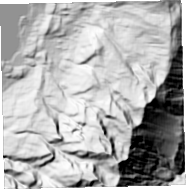

In [3]:
from mapsmith.engines import raster

raster.reproject_raster(str(dem_path), str(data / 'baldo_dem_utm.tif'),
                        target_crs='EPSG:32632', resampling='bilinear', resolution=30.0)
slope = whitebox_engine.slope(str(data / 'baldo_dem_utm.tif'), str(data / 'baldo_slope.tif'),
                              units='degrees')
whitebox_engine.hillshade(str(data / 'baldo_dem_utm.tif'), str(data / 'baldo_hillshade.tif'),
                          azimuth=315, altitude=35)
show(data / 'baldo_hillshade.tif')

## NDVI, and the offset that is already in the pixels

The Sentinel-2 catalogue entry for this item (Element 84 Earth Search) declares
`scale 0.0001, offset -0.1` for both bands; the files themselves declare
neither. Deep water in Lake Garda is dark in the near infrared — a reflectance
of one to three per cent — so its raw value settles which reading is right:

In [4]:
# Measured by fetch_copernicus.py on the full band, off Malcesine, just west
# of the clip, and stored in the clip's tags. Read inside the `with`: a closed
# dataset answers every tag question with an empty dict.
with rasterio.open(s2_path) as s2:
    water = int(s2.tags()['DEEP_WATER_NIR_DN'])
print('deep water, raw near-infrared value:', water)
print('reflectance, scale only:          ', round(water * 0.0001, 4))
print('reflectance, scale and the offset:', round(water * 0.0001 - 0.1, 4), '<- impossible')

deep water, raw near-infrared value: 303
reflectance, scale only:           0.0303
reflectance, scale and the offset: -0.0697 <- impossible


A negative reflectance does not exist: the offset was applied when these
files were produced, and applying it again shifts every band by 0.1 — an NDVI
that is wrong on every pixel and still between -1 and 1. The clip therefore
declares the scale and an offset of 0 (the measurement is in
`fetch_copernicus.py`, and holds for this item only). `band_math` applies what
the file declares **and says so in the manifest**; it cannot know what a
catalogue it never read says.

scale and offset applied: ['b1: value * 0.0001 + 0.0', 'b2: value * 0.0001 + 0.0']


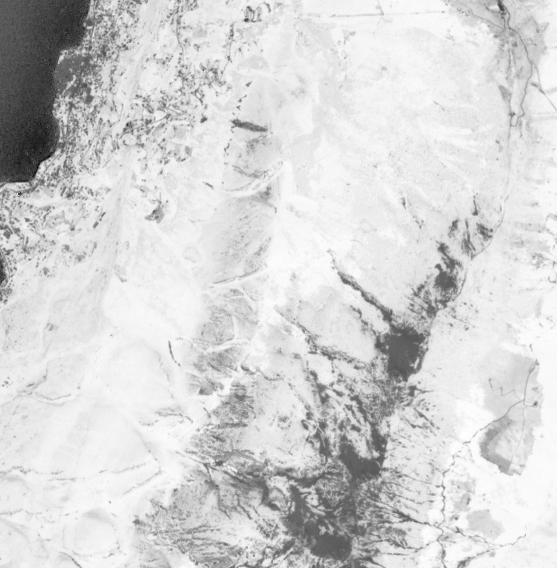

In [5]:
ndvi = raster.band_math(str(s2_path), str(data / 'baldo_ndvi.tif'), '(b2 - b1) / (b2 + b1)')
print('scale and offset applied:', ndvi['scale_offset_applied'])
show(data / 'baldo_ndvi.tif')

## The treeline, read off the two rasters

A point every 100 m over the window, the NDVI read at each (nearest: the
point should take its own 10 m cell, not a blend with the lake next to it) and
the height from the reprojected DEM (bilinear: a continuous surface). The table
groups them by 250 m of height, after dropping the lake (NDVI below 0).

In [6]:
import geopandas as gpd
from shapely.geometry import Point
from mapsmith.engines import sampling

with rasterio.open(data / 'baldo_ndvi.tif') as src:
    left, bottom, right, top = src.bounds
grid = [Point(x, y) for x in np.arange(left + 50, right, 100) for y in np.arange(bottom + 50, top, 100)]
gpd.GeoDataFrame({'id': range(len(grid))}, geometry=grid, crs='EPSG:32632').to_parquet(data / 'baldo_points.parquet')

sampling.sample_raster_at_points(str(data / 'baldo_ndvi.tif'), str(data / 'baldo_points.parquet'),
                                 str(data / 'baldo_points_ndvi.parquet'), 'nearest', column_name='ndvi')
sampling.sample_raster_at_points(str(data / 'baldo_dem_utm.tif'), str(data / 'baldo_points_ndvi.parquet'),
                                 str(data / 'baldo_points_both.parquet'), 'bilinear', column_name='height')

points = gpd.read_parquet(data / 'baldo_points_both.parquet').dropna(subset=['ndvi', 'height'])
land = points[points['ndvi'] >= 0]
belts = (land.assign(belt=(land['height'] // 250 * 250).astype(int))
             .groupby('belt')['ndvi'].agg(['count', 'mean']).round(2))
print(len(points) - len(land), 'points on the lake dropped')
belts

72 points on the lake dropped


,count,mean
belt,,
0,246,0.55
250,300,0.77
500,305,0.83
750,266,0.83
1000,275,0.83
1250,414,0.83
1500,509,0.77
1750,470,0.66
2000,136,0.45


The NDVI holds at about 0.83 from 500 to 1,500 m and falls to 0.45 above
2,000 m: the treeline, read off two rasters that were never in the same CRS.
The first version of this table had 138 more points in its lowest belt. The
DEM declared no nodata, so the reprojection filled its edges with a height of
0 m — and its own `fill_is_distinguishable` check went red and said so. The
clip now declares the product's invalid value, -32767, as nodata.

## What the manifests say

Each output carries its own record. The reprojection names its method and the
transformation PROJ was asked for; the NDVI records the scale it applied.

In [7]:
from mapsmith.provenance import read_provenance

for name in ('baldo_dem_utm.tif', 'baldo_ndvi.tif', 'baldo_slope.tif'):
    manifest = read_provenance(str(data / name))
    print(name, '|', manifest['operation'], '| producer', manifest['producer']['version'])
    print('   parameters:', manifest['parameters'])
    print('   checks:', [(c['name'], c['passed']) for c in manifest['verification']])
    for note in manifest['notes']:
        print('   note:', note[:160])

baldo_dem_utm.tif | reproject_raster | producer 0.7.1
   parameters: {'target_crs': 'EPSG:32632', 'resampling': 'bilinear', 'resolution': 30.0, 'target_shape': [190, 186]}
   checks: [('crs_matches', True), ('x-mapsmith:datum_shift_applied', True), ('result_not_empty', True), ('x-mapsmith:cell_size_is_what_was_asked', True), ('x-mapsmith:fill_is_distinguishable', True)]
baldo_ndvi.tif | band_math | producer 0.7.1
   parameters: {'expression': '(b2 - b1) / (b2 + b1)', 'bands_used': [1, 2]}
   checks: [('shape_preserved', True), ('x-mapsmith:written_as_float', True), ('result_not_empty', True)]
   note: declared scale and offset applied before the expression — b1: value * 0.0001 + 0.0; b2: value * 0.0001 + 0.0. GDAL leaves this to the caller, so an index comput
baldo_slope.tif | slope | producer 0.7.1
   parameters: {'units': 'degrees', 'z_factor': 1.0}
   checks: [('crs_present', True), ('crs_matches', True), ('shape_preserved', True), ('result_not_empty', True), ('values_in_expected_ra